In [1]:
# setup/repo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
!rm -rf PGST
!git clone --quiet https://github.com/mickdeines/PGST/
os.chdir("PGST")

Loaded 98,925 rows. Columns: ['time_pacific', 't2m_F']


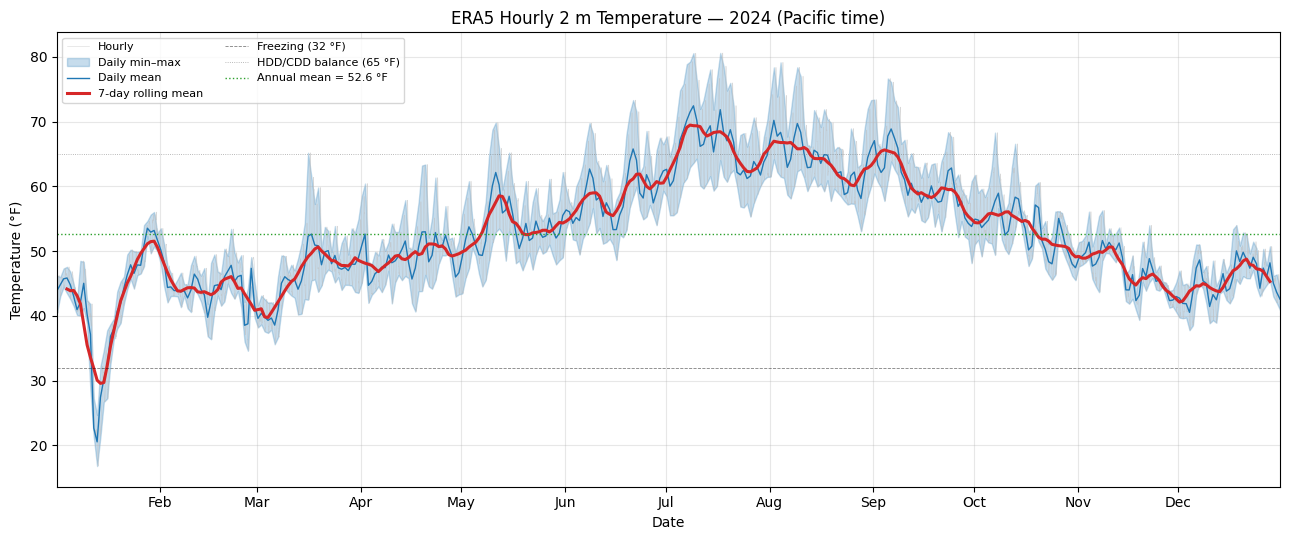


2024 summary (°F):
  Mean:    52.59
  Min:     16.79  on 2024-01-13 07:00:00-08:00
  Max:     80.61  on 2024-07-17 18:00:00-07:00
  HDD65:     4645 °F·day
  CDD65:      103 °F·day


In [2]:
# ---- Plot ERA5 hourly temperatures for a chosen year ---------------------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

CSV_FILE = "ERA5 Hourly Temperatures 2015-2026.csv"
YEAR     = 2024            # <-- change to the year you want
SAVE_PNG = True

# ---- 1. Load --------------------------------------------------------------
df = pd.read_csv(CSV_FILE)
print(f"Loaded {len(df):,} rows. Columns: {list(df.columns)}")

# ---- 2. Parse timestamps (mixed PST/PDT offsets) -------------------------
# Parse as UTC first to handle the mixed offsets, then convert back to Pacific.
df["time_pacific"] = (
    pd.to_datetime(df["time_pacific"], utc=True)
      .dt.tz_convert("US/Pacific")
)
df = df.set_index("time_pacific").sort_index()

# Temperatures are already in °F in this file
df["T_F"] = df["t2m_F"]

# ---- 3. Slice the year ---------------------------------------------------
# Use boolean masking instead of string slicing — safer with tz-aware index.
mask = df.index.year == YEAR
year_df = df.loc[mask]
if year_df.empty:
    raise ValueError(f"No rows for {YEAR}. "
                     f"Data spans {df.index.min()} to {df.index.max()}.")

# Daily aggregates
daily = year_df["T_F"].resample("1D")
d_mean, d_min, d_max = daily.mean(), daily.min(), daily.max()
rolling7 = d_mean.rolling(7, center=True).mean()

# ---- 4. Plot -------------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 5.5))

ax.plot(year_df.index, year_df["T_F"],
        color="0.75", lw=0.4, alpha=0.6, label="Hourly")

ax.fill_between(d_min.index, d_min, d_max,
                color="C0", alpha=0.25, label="Daily min–max")

ax.plot(d_mean.index, d_mean, color="C0", lw=1.0, label="Daily mean")
ax.plot(rolling7.index, rolling7, color="C3", lw=2.2,
        label="7-day rolling mean")

# Reference lines
ax.axhline(32, color="k", lw=0.6, ls="--", alpha=0.5, label="Freezing (32 °F)")
ax.axhline(65, color="0.4", lw=0.6, ls=":", alpha=0.6,
           label="HDD/CDD balance (65 °F)")
annual_mean = year_df["T_F"].mean()
ax.axhline(annual_mean, color="C2", lw=1.0, ls=":",
           label=f"Annual mean = {annual_mean:.1f} °F")

ax.set_title(f"ERA5 Hourly 2 m Temperature — {YEAR} (Pacific time)")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°F)")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.set_xlim(pd.Timestamp(f"{YEAR}-01-01", tz="US/Pacific"),
            pd.Timestamp(f"{YEAR}-12-31", tz="US/Pacific"))
ax.grid(alpha=0.3)
ax.legend(loc="upper left", fontsize=8, ncols=2)
fig.tight_layout()

if SAVE_PNG:
    fig.savefig(f"ERA5_temperature_{YEAR}.png", dpi=150)
plt.show()

# ---- 5. Quick stats ------------------------------------------------------
print(f"\n{YEAR} summary (°F):")
print(f"  Mean:   {year_df['T_F'].mean():6.2f}")
print(f"  Min:    {year_df['T_F'].min():6.2f}  on {year_df['T_F'].idxmin()}")
print(f"  Max:    {year_df['T_F'].max():6.2f}  on {year_df['T_F'].idxmax()}")
print(f"  HDD65:  {((65 - d_mean).clip(lower=0)).sum():7.0f} °F·day")
print(f"  CDD65:  {((d_mean - 65).clip(lower=0)).sum():7.0f} °F·day")

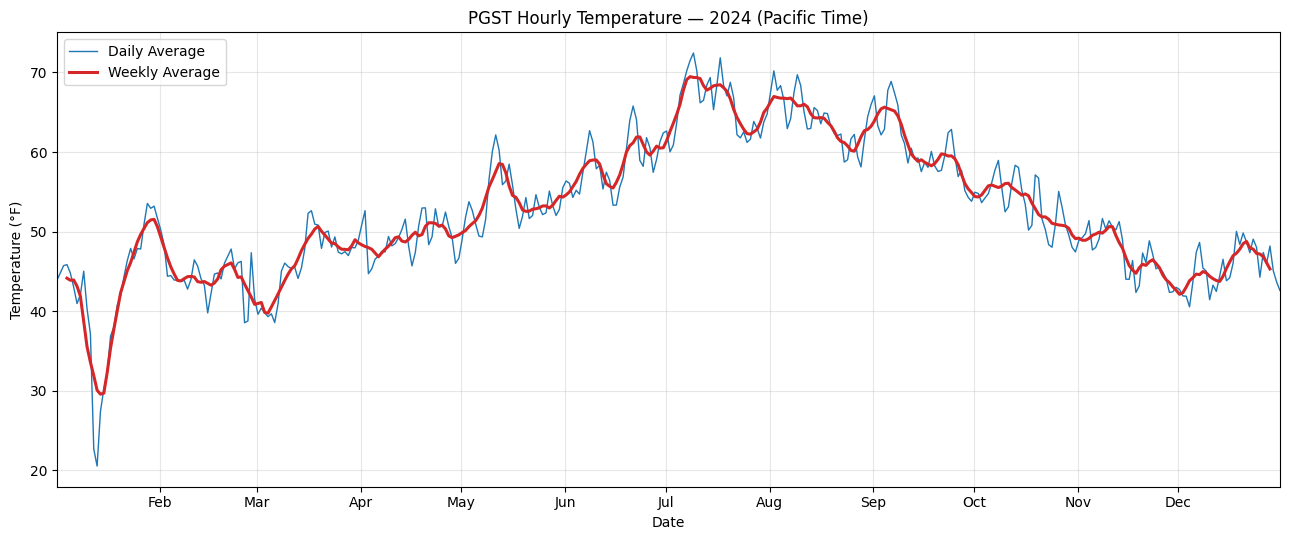

In [3]:
# ---- Plot ERA5 hourly temperatures for a chosen year ---------------------
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

CSV_FILE = "ERA5 Hourly Temperatures 2015-2026.csv"
YEAR     = 2024
SAVE_PNG = True

# ---- 1. Load --------------------------------------------------------------
df = pd.read_csv(CSV_FILE)

# ---- 2. Parse timestamps (mixed PST/PDT offsets) -------------------------
df["time_pacific"] = (
    pd.to_datetime(df["time_pacific"], utc=True)
      .dt.tz_convert("US/Pacific")
)
df = df.set_index("time_pacific").sort_index()

# ---- 3. Slice the year ---------------------------------------------------
year_df = df.loc[df.index.year == YEAR]
if year_df.empty:
    raise ValueError(f"No rows for {YEAR}. "
                     f"Data spans {df.index.min()} to {df.index.max()}.")

# ---- 4. Aggregates -------------------------------------------------------
d_mean   = year_df["t2m_F"].resample("1D").mean()
rolling7 = d_mean.rolling(7, center=True).mean()

# ---- 5. Plot -------------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 5.5))

ax.plot(d_mean.index,   d_mean,   color="C0", lw=1.0, label="Daily Average")
ax.plot(rolling7.index, rolling7, color="C3", lw=2.2, label="Weekly Average")

ax.set_title(f"PGST Hourly Temperature — {YEAR} (Pacific Time)")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°F)")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.set_xlim(pd.Timestamp(f"{YEAR}-01-01", tz="US/Pacific"),
            pd.Timestamp(f"{YEAR}-12-31", tz="US/Pacific"))
ax.grid(alpha=0.3)
ax.legend(loc="upper left")
fig.tight_layout()

if SAVE_PNG:
    fig.savefig(f"ERA5_temperature_{YEAR}.png", dpi=150)
plt.show()

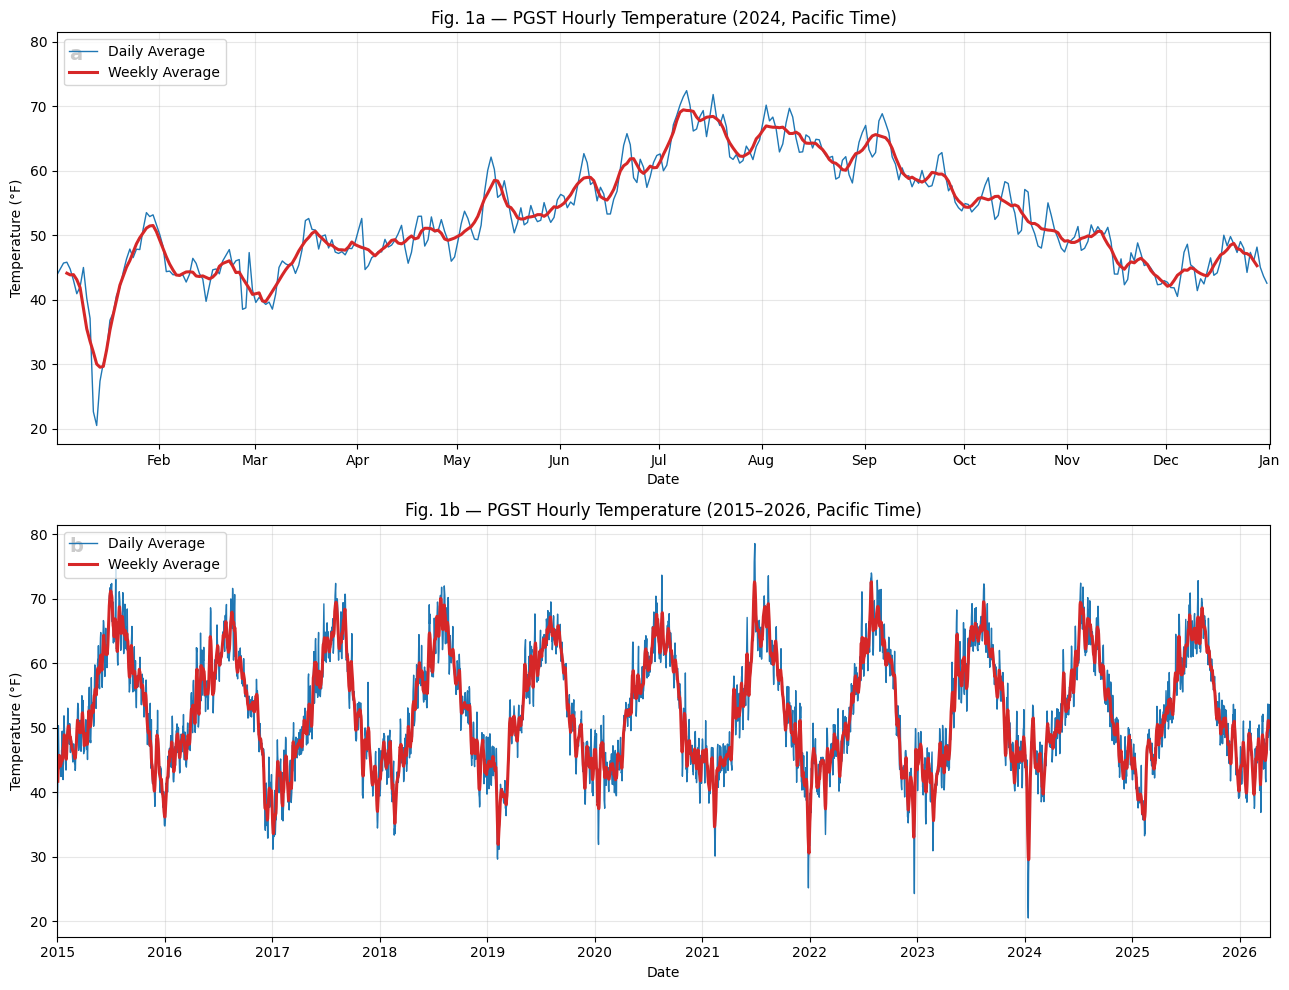

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ---- Configuration -------------------------------------------------------
CSV_FILE    = "ERA5 Hourly Temperatures 2015-2026.csv"
YEAR        = 2024
SAVE_PNG    = True
OUTPUT_PNG  = "ERA5_temperature_Fig1ab.png"

# ---- 1. Load -------------------------------------------------------------
df = pd.read_csv(CSV_FILE)

# ---- 2. Parse timestamps (mixed PST/PDT offsets) ------------------------
df["time_pacific"] = (
    pd.to_datetime(df["time_pacific"], utc=True)
      .dt.tz_convert("US/Pacific")
)
df = df.set_index("time_pacific").sort_index()

# ---- 3. Create full-period daily and weekly series ----------------------
full_daily_mean = df["t2m_F"].resample("1D").mean()
full_rolling7   = full_daily_mean.rolling(7, center=True).mean()

# ---- 4. Slice chosen year for panel 1a ----------------------------------
year_df = df.loc[df.index.year == YEAR]
if year_df.empty:
    raise ValueError(
        f"No rows for {YEAR}. Data spans {df.index.min()} to {df.index.max()}."
    )

year_daily_mean = year_df["t2m_F"].resample("1D").mean()
year_rolling7   = year_daily_mean.rolling(7, center=True).mean()

# ---- 5. Build Fig. 1a and 1b --------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(13, 10), sharey=True)
ax1, ax2 = axes

# ---- Panel 1a: selected year --------------------------------------------
ax1.plot(year_daily_mean.index, year_daily_mean, color="C0", lw=1.0, label="Daily Average")
ax1.plot(year_rolling7.index, year_rolling7, color="C3", lw=2.2, label="Weekly Average")
ax1.set_title(f"Fig. 1a — PGST Hourly Temperature ({YEAR}, Pacific Time)")
ax1.set_xlabel("Date")
ax1.set_ylabel("Temperature (°F)")
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax1.set_xlim(
    pd.Timestamp(f"{YEAR}-01-01", tz="US/Pacific"),
    pd.Timestamp(f"{YEAR}-12-31 23:59:59", tz="US/Pacific")
)
ax1.grid(alpha=0.3)
ax1.legend(loc="upper left")
ax1.text(0.01, 0.97, "a", transform=ax1.transAxes, fontsize=14, fontweight="bold", va="top")

# ---- Panel 1b: full 2015-2026 period ------------------------------------
ax2.plot(full_daily_mean.index, full_daily_mean, color="C0", lw=1.0, label="Daily Average")
ax2.plot(full_rolling7.index, full_rolling7, color="C3", lw=2.2, label="Weekly Average")
ax2.set_title("Fig. 1b — PGST Hourly Temperature (2015–2026, Pacific Time)")
ax2.set_xlabel("Date")
ax2.set_ylabel("Temperature (°F)")
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.set_xlim(full_daily_mean.index.min(), full_daily_mean.index.max())
ax2.grid(alpha=0.3)
ax2.legend(loc="upper left")
ax2.text(0.01, 0.97, "b", transform=ax2.transAxes, fontsize=14, fontweight="bold", va="top")

fig.tight_layout()

if SAVE_PNG:
    fig.savefig(OUTPUT_PNG, dpi=150, bbox_inches="tight")

plt.show()


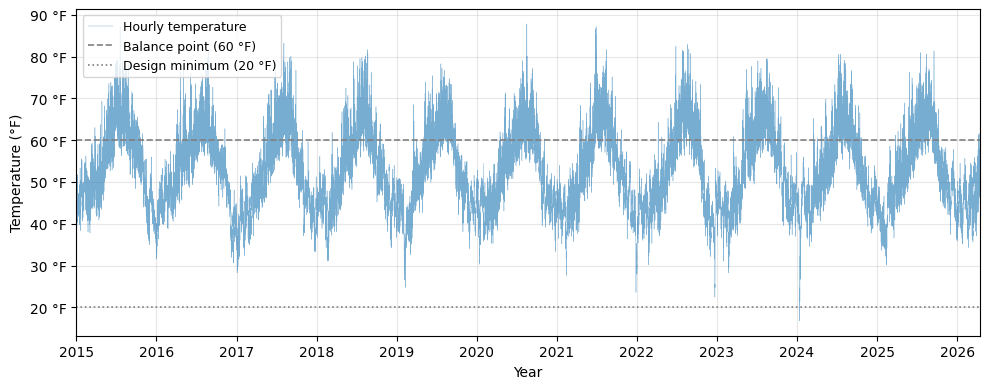

Hours below 20 °F: 11
                               t2m_F
time_pacific                        
2024-01-13 01:00:00-08:00  19.121857
2024-01-13 02:00:00-08:00  18.057407
2024-01-13 03:00:00-08:00  17.787447
2024-01-13 04:00:00-08:00  17.556249
2024-01-13 05:00:00-08:00  17.398132
2024-01-13 06:00:00-08:00  17.113609
2024-01-13 07:00:00-08:00  16.787305
2024-01-13 08:00:00-08:00  16.814130
2024-01-13 09:00:00-08:00  17.290068
2024-01-13 10:00:00-08:00  17.956296
2024-01-13 11:00:00-08:00  19.171243


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

CSV_FILE = "ERA5 Hourly Temperatures 2015-2026.csv"
SAVE_PNG = True
OUTPUT_PNG = "ERA5_temperature_C1.png"

# ---- 1. Load and parse ---------------------------------------------------
df = pd.read_csv(CSV_FILE)
df["time_pacific"] = (
    pd.to_datetime(df["time_pacific"], utc=True)
      .dt.tz_convert("US/Pacific")
)
df = df.set_index("time_pacific").sort_index()

# ---- 2. Plot -------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(df.index, df["t2m_F"],
        color="C0", lw=0.3, alpha=0.6, label="Hourly temperature")

ax.axhline(60, color="0.5", lw=1.2, ls="--", label="Balance point (60 °F)")
ax.axhline(20, color="0.5", lw=1.2, ls=":",  label="Design minimum (20 °F)")

ax.set_xlabel("Year")
ax.set_ylabel("Temperature (°F)")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%d °F"))
ax.set_xlim(df.index.min(), df.index.max())
ax.grid(alpha=0.3)
ax.legend(loc="upper left", fontsize=9)
fig.tight_layout()

if SAVE_PNG:
    fig.savefig(OUTPUT_PNG, dpi=150, bbox_inches="tight")
plt.show()

# ---- 3. Flag hours below design minimum ----------------------------------
below_20 = df[df["t2m_F"] < 20]
print(f"Hours below 20 °F: {len(below_20)}")
print(below_20[["t2m_F"]])